In [3]:
import io
import sys
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.notebook import tqdm
from IPython.display import display, HTML

# 1. Align paths with your workspace layout
sys.path.append(r"D:\Code\query-earth\vlm")
from model import VLM

def load_model_from_notebook(checkpoint_path: str, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    train_args = ckpt["args"]
    model, processor, tokenizer = VLM.build_with_processor(
        text_model_name=train_args.get("text_model_name", "prajjwal1/bert-tiny"),
        vision_model_name=train_args.get("vision_model_name", "facebook/dino-vits16"),
        proj_dim=train_args["proj_dim"],
        quantisation=train_args.get("quantisation", None),    )
    model.load_state_dict(ckpt["model_state_dict"], strict=False)
    model.to(device).eval()
    print(f"Successfully loaded checkpoint: {checkpoint_path} (Epoch {ckpt.get('epoch')})")
    return model, processor, tokenizer

2026-07-20 08:27:31,989 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-20 08:27:31,992 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-20 08:27:32,259 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
2026-07-20 08:27:32,635 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-07-20 08:27:32,982 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-07-20 08:27:33,332 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/pytorch_model.b

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-07-20 08:27:34,807 | INFO | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
2026-07-20 08:27:35,171 | INFO | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-07-20 08:27:35,555 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-07-20 08:27:35,603 | INFO | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-20 08:27:35,894 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302 Found"
2026-07-20 08:27:35,946 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1

Successfully loaded checkpoint: D:\Code\query-earth\vlm\runs\checkpoint_epoch9.pt (Epoch 10)
Reading Parquet layout...
Processing 51533 images...


  0%|          | 0/403 [00:00<?, ?it/s]

Rank 1 | Parquet Row Index: 45588 | Cosine Similarity: 0.6134


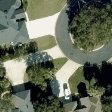

--------------------------------------------------
Rank 2 | Parquet Row Index: 4814 | Cosine Similarity: 0.6072


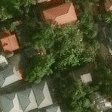

--------------------------------------------------
Rank 3 | Parquet Row Index: 8179 | Cosine Similarity: 0.5529


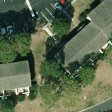

--------------------------------------------------
Rank 4 | Parquet Row Index: 24711 | Cosine Similarity: 0.5493


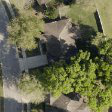

--------------------------------------------------
Rank 5 | Parquet Row Index: 24911 | Cosine Similarity: 0.5486


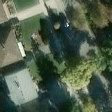

--------------------------------------------------
Rank 6 | Parquet Row Index: 38325 | Cosine Similarity: 0.5350


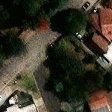

--------------------------------------------------
Rank 7 | Parquet Row Index: 9347 | Cosine Similarity: 0.5301


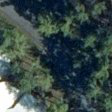

--------------------------------------------------
Rank 8 | Parquet Row Index: 25272 | Cosine Similarity: 0.5290


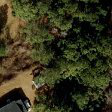

--------------------------------------------------
Rank 9 | Parquet Row Index: 30967 | Cosine Similarity: 0.5273


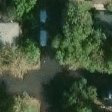

--------------------------------------------------
Rank 10 | Parquet Row Index: 21197 | Cosine Similarity: 0.5135


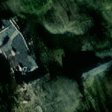

--------------------------------------------------


In [3]:
# --- CONFIGURATION PARAMETERS ---
CHECKPOINT_PATH = r"D:\Code\query-earth\vlm\runs\checkpoint_epoch9.pt"
PARQUET_PATH = r"E:\Data\query-earth\vlm_captions_2.parquet"
IMAGE_COLUMN = "image_bytes"  # The name of your image bytes column in the parquet
QUERY_TEXT = "dense residential area near a circular cloverleaf interchange"
BATCH_SIZE = 128
TOP_K = 10
# --------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize Model & Pipeline
model, processor, tokenizer = load_model_from_notebook(CHECKPOINT_PATH, device)

# 2. Encode the interactive text query
with torch.no_grad():
    tok = tokenizer([QUERY_TEXT], padding=True, truncation=True, max_length=77, return_tensors="pt").to(device)
    text_embed = model.encode_text(tok["input_ids"], tok["attention_mask"], normalize=True).squeeze(0)

# 3. Stream in image column from Parquet
print("Reading Parquet layout...")
df = pd.read_parquet(PARQUET_PATH, columns=[IMAGE_COLUMN])
total_images = len(df)

# 4. Batch encode image bytes
image_embeddings_list = []
print(f"Processing {total_images} images...")

for i in tqdm(range(0, total_images, BATCH_SIZE)):
    batch_df = df.iloc[i : i + BATCH_SIZE]
    batch_tensors = []
    
    for idx, row in batch_df.iterrows():
        try:
            img = Image.open(io.BytesIO(row[IMAGE_COLUMN])).convert("RGB")
            pixel_tensor = processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
            batch_tensors.append(pixel_tensor)
        except Exception:
            # Fallback tensor if a row's binary structure is corrupted
            batch_tensors.append(torch.zeros(3, 224, 224))
            
    if batch_tensors:
        pixel_values = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            img_embeds = model.encode_image(pixel_values, normalize=True)
            image_embeddings_list.append(img_embeds.cpu())

all_image_embeds = torch.cat(image_embeddings_list, dim=0).to(device)

# 5. Score via Matrix Multiplication & Extract top matches
scores = all_image_embeds @ text_embed
top_scores, top_indices = torch.topk(scores, k=min(TOP_K, total_images))

# 6. Render the results visually inside the notebook
display(HTML(f"<h3>Query: <i>'{QUERY_TEXT}'</i></h3><hr>"))

for rank, (score, idx) in enumerate(zip(top_scores.tolist(), top_indices.tolist()), 1):
    raw_bytes = df.iloc[idx][IMAGE_COLUMN]
    img = Image.open(io.BytesIO(raw_bytes))
    
    # Optional: Resize large images downward to fit cleanly in notebook output cells
    img.thumbnail((256, 256)) 
    
    print(f"Rank {rank} | Parquet Row Index: {idx} | Cosine Similarity: {score:.4f}")
    display(img)
    print("-" * 50)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Successfully loaded checkpoint: D:\Code\query-earth\vlm\runs\checkpoint_epoch26.pt (Epoch 27)
Reading Parquet layout...
Processing 51533 images...


  0%|          | 0/51 [00:00<?, ?it/s]

Rank 1 | Parquet Row Index: 6972 | Cosine Similarity: 0.6402


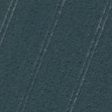

--------------------------------------------------
Rank 2 | Parquet Row Index: 27237 | Cosine Similarity: 0.6210


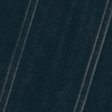

--------------------------------------------------
Rank 3 | Parquet Row Index: 40818 | Cosine Similarity: 0.5685


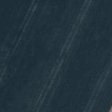

--------------------------------------------------
Rank 4 | Parquet Row Index: 11903 | Cosine Similarity: 0.5645


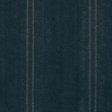

--------------------------------------------------
Rank 5 | Parquet Row Index: 20870 | Cosine Similarity: 0.5641


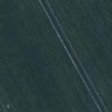

--------------------------------------------------
Rank 6 | Parquet Row Index: 2684 | Cosine Similarity: 0.5621


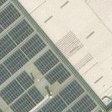

--------------------------------------------------
Rank 7 | Parquet Row Index: 9192 | Cosine Similarity: 0.5565


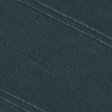

--------------------------------------------------
Rank 8 | Parquet Row Index: 28753 | Cosine Similarity: 0.5384


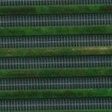

--------------------------------------------------
Rank 9 | Parquet Row Index: 37922 | Cosine Similarity: 0.5381


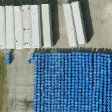

--------------------------------------------------
Rank 10 | Parquet Row Index: 4541 | Cosine Similarity: 0.5321


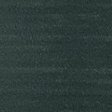

--------------------------------------------------


In [4]:
import pandas as pd
import torch

# --- CONFIGURATION PARAMETERS ---
CHECKPOINT_PATH = r"D:\Code\query-earth\vlm\runs\checkpoint_epoch26.pt"
PARQUET_PATH = r"E:\Data\query-earth\vlm_captions_2.parquet"
IMAGE_COLUMN = "image_bytes"  # The name of your image bytes column in the parquet
QUERY_TEXT = "solar panels"
BATCH_SIZE = 1024
TOP_K = 10
# --------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize Model & Pipeline
model, processor, tokenizer = load_model_from_notebook(CHECKPOINT_PATH, device)

# 2. Encode the interactive text query
with torch.no_grad():
    tok = tokenizer([QUERY_TEXT], padding=True, truncation=True, max_length=77, return_tensors="pt").to(device)
    text_embed = model.encode_text(tok["input_ids"], tok["attention_mask"], normalize=True).squeeze(0)

# 3. Stream in image column from Parquet
print("Reading Parquet layout...")
df = pd.read_parquet(PARQUET_PATH, columns=[IMAGE_COLUMN])
total_images = len(df)

# 4. Batch encode image bytes
image_embeddings_list = []
print(f"Processing {total_images} images...")

for i in tqdm(range(0, total_images, BATCH_SIZE)):
    batch_df = df.iloc[i : i + BATCH_SIZE]
    batch_tensors = []
    
    for idx, row in batch_df.iterrows():
        try:
            img = Image.open(io.BytesIO(row[IMAGE_COLUMN])).convert("RGB")
            pixel_tensor = processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
            batch_tensors.append(pixel_tensor)
        except Exception:
            # Fallback tensor if a row's binary structure is corrupted
            batch_tensors.append(torch.zeros(3, 224, 224))
            
    if batch_tensors:
        pixel_values = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            img_embeds = model.encode_image(pixel_values, normalize=True)
            image_embeddings_list.append(img_embeds.cpu())

all_image_embeds = torch.cat(image_embeddings_list, dim=0).to(device)

# 5. Score via Matrix Multiplication & Extract top matches
scores = all_image_embeds @ text_embed
top_scores, top_indices = torch.topk(scores, k=min(TOP_K, total_images))

# 6. Render the results visually inside the notebook
display(HTML(f"<h3>Query: <i>'{QUERY_TEXT}'</i></h3><hr>"))

for rank, (score, idx) in enumerate(zip(top_scores.tolist(), top_indices.tolist()), 1):
    raw_bytes = df.iloc[idx][IMAGE_COLUMN]
    img = Image.open(io.BytesIO(raw_bytes))
    
    # Optional: Resize large images downward to fit cleanly in notebook output cells
    img.thumbnail((256, 256)) 
    
    print(f"Rank {rank} | Parquet Row Index: {idx} | Cosine Similarity: {score:.4f}")
    display(img)
    print("-" * 50)

2026-07-20 08:36:15,019 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-20 08:36:15,277 | INFO | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
2026-07-20 08:36:15,646 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-07-20 08:36:15,985 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-07-20 08:36:16,327 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
2026-07-20 08:36:16,670 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 N

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-07-20 08:36:17,367 | INFO | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/main "HTTP/1.1 200 OK"
2026-07-20 08:36:17,744 | INFO | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
2026-07-20 08:36:18,075 | INFO | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-20 08:36:18,129 | INFO | HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-07-20 08:36:18,419 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-07-20 08:36:18,466 | INFO | HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
202

Successfully loaded checkpoint: D:\Code\query-earth\vlm\runs\checkpoint_epoch9.pt (Epoch 10)
Reading Parquet layout...
Processing 51533 images...


  0%|          | 0/51 [00:00<?, ?it/s]

Rank 1 | Parquet Row Index: 31305 | Cosine Similarity: 0.6943


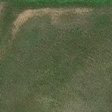

--------------------------------------------------
Rank 2 | Parquet Row Index: 32087 | Cosine Similarity: 0.6517


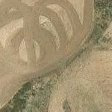

--------------------------------------------------
Rank 3 | Parquet Row Index: 17607 | Cosine Similarity: 0.6423


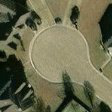

--------------------------------------------------
Rank 4 | Parquet Row Index: 47909 | Cosine Similarity: 0.6350


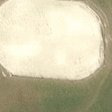

--------------------------------------------------
Rank 5 | Parquet Row Index: 20032 | Cosine Similarity: 0.6253


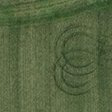

--------------------------------------------------
Rank 6 | Parquet Row Index: 36752 | Cosine Similarity: 0.6154


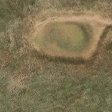

--------------------------------------------------
Rank 7 | Parquet Row Index: 17680 | Cosine Similarity: 0.6110


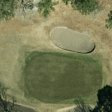

--------------------------------------------------
Rank 8 | Parquet Row Index: 36560 | Cosine Similarity: 0.6085


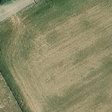

--------------------------------------------------
Rank 9 | Parquet Row Index: 42052 | Cosine Similarity: 0.5980


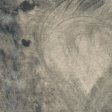

--------------------------------------------------
Rank 10 | Parquet Row Index: 4391 | Cosine Similarity: 0.5911


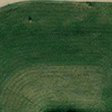

--------------------------------------------------


In [5]:
# --- CONFIGURATION PARAMETERS ---
CHECKPOINT_PATH = r"D:\Code\query-earth\vlm\runs\checkpoint_epoch9.pt"
PARQUET_PATH = r"E:\Data\query-earth\vlm_captions_2.parquet"
IMAGE_COLUMN = "image_bytes"  # The name of your image bytes column in the parquet
QUERY_TEXT = "circular farmlands"
BATCH_SIZE = 1024
TOP_K = 10
# --------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Initialize Model & Pipeline
model, processor, tokenizer = load_model_from_notebook(CHECKPOINT_PATH, device)

# 2. Encode the interactive text query
with torch.no_grad():
    tok = tokenizer([QUERY_TEXT], padding=True, truncation=True, max_length=77, return_tensors="pt").to(device)
    text_embed = model.encode_text(tok["input_ids"], tok["attention_mask"], normalize=True).squeeze(0)

# 3. Stream in image column from Parquet
print("Reading Parquet layout...")
df = pd.read_parquet(PARQUET_PATH, columns=[IMAGE_COLUMN])
total_images = len(df)

# 4. Batch encode image bytes
image_embeddings_list = []
print(f"Processing {total_images} images...")

for i in tqdm(range(0, total_images, BATCH_SIZE)):
    batch_df = df.iloc[i : i + BATCH_SIZE]
    batch_tensors = []
    
    for idx, row in batch_df.iterrows():
        try:
            img = Image.open(io.BytesIO(row[IMAGE_COLUMN])).convert("RGB")
            pixel_tensor = processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
            batch_tensors.append(pixel_tensor)
        except Exception:
            # Fallback tensor if a row's binary structure is corrupted
            batch_tensors.append(torch.zeros(3, 224, 224))
            
    if batch_tensors:
        pixel_values = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            img_embeds = model.encode_image(pixel_values, normalize=True)
            image_embeddings_list.append(img_embeds.cpu())

all_image_embeds = torch.cat(image_embeddings_list, dim=0).to(device)

# 5. Score via Matrix Multiplication & Extract top matches
scores = all_image_embeds @ text_embed
top_scores, top_indices = torch.topk(scores, k=min(TOP_K, total_images))

# 6. Render the results visually inside the notebook
display(HTML(f"<h3>Query: <i>'{QUERY_TEXT}'</i></h3><hr>"))

for rank, (score, idx) in enumerate(zip(top_scores.tolist(), top_indices.tolist()), 1):
    raw_bytes = df.iloc[idx][IMAGE_COLUMN]
    img = Image.open(io.BytesIO(raw_bytes))
    
    # Optional: Resize large images downward to fit cleanly in notebook output cells
    img.thumbnail((256, 256)) 
    
    print(f"Rank {rank} | Parquet Row Index: {idx} | Cosine Similarity: {score:.4f}")
    display(img)
    print("-" * 50)